### Load the dataset and construct the network

In [ ]:
import pandas as pd
import networkx as nx

# List of your 6 dataset URLs
files = [
    "https://raw.githubusercontent.com/juyy-vio/network-science/refs/heads/main/out1_1.txt",
    "https://raw.githubusercontent.com/juyy-vio/network-science/refs/heads/main/out1_2.txt",
    "https://raw.githubusercontent.com/juyy-vio/network-science/refs/heads/main/out1_3.txt",
    "https://raw.githubusercontent.com/juyy-vio/network-science/refs/heads/main/out1_4.txt",
    "https://raw.githubusercontent.com/juyy-vio/network-science/refs/heads/main/out1_5.txt",
    "https://raw.githubusercontent.com/juyy-vio/network-science/refs/heads/main/out1_6.txt",
]
g10_frames = []

for f in files:
    df = pd.read_csv(f, sep="\t", header=None, names=["graph","src","dst","attributes"])
    g10_frames.append(df[df["graph"] == "g10"])

# Combine all g10 rows from all 6 datasets
g10_all = pd.concat(g10_frames, ignore_index=True)

# Extract edges only
edges = g10_all[["src", "dst"]]

# Build the combined graph
G10 = nx.from_pandas_edgelist(edges, "src", "dst", create_using=nx.DiGraph())

print("Number of Nodes:", G10.number_of_nodes())
print("Number of Edges:", G10.number_of_edges())

Number of Nodes: 8221
Number of Edges: 19089


### Average degree

In [ ]:
avg_d=G10.number_of_edges()/G10.number_of_nodes()
print(f"The average degree of the network is {avg_d}")

The average degree of the network is 2.321980294368082


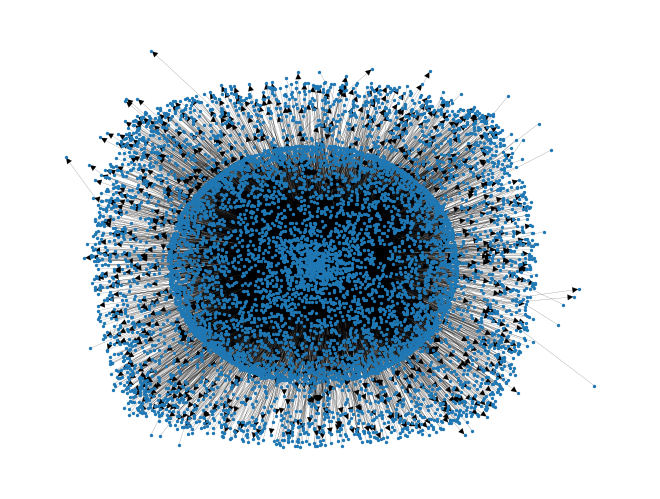

In [ ]:
nx.draw(G10,node_size=2, width=0.1)

### Degree distribution

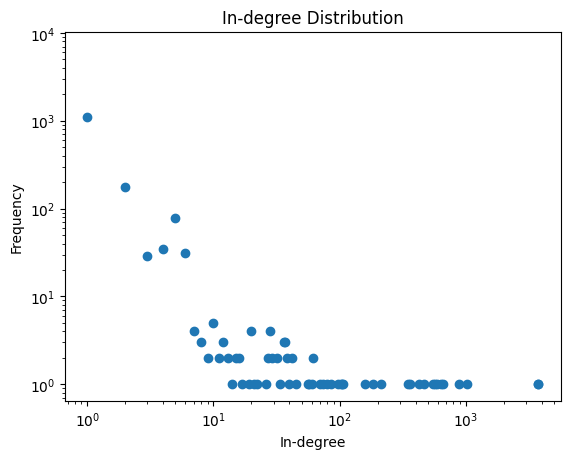

In [ ]:
# step 1: in_degrees and out_degrees of all nodes
in_degrees=[d for _,d in G10.in_degree()]
out_degrees=[d for _,d in G10.out_degree()]

# step 2: Convert to degree distribution
from collections import Counter

in_count = Counter(in_degrees)
out_count = Counter(out_degrees)

# step 3: sort values
in_deg, in_freq = zip(*sorted(in_count.items()))
out_deg, out_freq = zip(*sorted(out_count.items()))

# step 4: plot in_degree distribution
import matplotlib.pyplot as plt
plt.figure()
plt.loglog(in_deg, in_freq, 'o')
plt.xlabel("In-degree")
plt.ylabel("Frequency")
plt.title("In-degree Distribution")
plt.show()

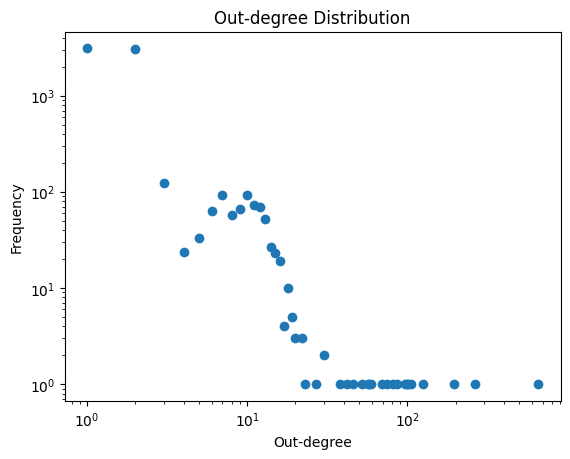

In [ ]:
# step 4: plot in_degree distribution
plt.figure()
plt.loglog(out_deg, out_freq, 'o')
plt.xlabel("Out-degree")
plt.ylabel("Frequency")
plt.title("Out-degree Distribution")
plt.show()

In [ ]:
import powerlaw

fit = powerlaw.Fit(in_degrees)

print("gamma:", fit.power_law.alpha)
print("xmin:", fit.power_law.xmin)

/usr/local/lib/python3.12/dist-packages/powerlaw/fitting.py:264: UserWarning: Values less than or equal to 0 in data. Throwing out 0 or negative values.
  warnings.warn("Values less than or equal to 0 in data. Throwing out 0 or negative values.")


Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 59/59 [00:00<00:00, 3722.16it/s]

gamma: 2.0653416663625235
xmin: 2.0



/usr/local/lib/python3.12/dist-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


In [ ]:
import powerlaw

fit = powerlaw.Fit(out_degrees)

print("gamma:", fit.power_law.alpha)
print("xmin:", fit.power_law.xmin)

/usr/local/lib/python3.12/dist-packages/powerlaw/fitting.py:264: UserWarning: Values less than or equal to 0 in data. Throwing out 0 or negative values.
  warnings.warn("Values less than or equal to 0 in data. Throwing out 0 or negative values.")


Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 41/41 [00:00<00:00, 801.79it/s]

gamma: 2.5686795107048876
xmin: 57.0



/usr/local/lib/python3.12/dist-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


In [ ]:
in_zero = [n for n, d in G10.in_degree() if d == 0]
print("Number of Nodes with in-degree = 0:", len(in_zero))

Nodes with in-degree = 0: 6682


In [ ]:
out_zero = [n for n, d in G10.out_degree() if d == 0]
print("number of Nodes with out-degree = 0:", len(out_zero))

Nodes with out-degree = 0: 1201


## Centrality analysis
### in-degree centrality and out-degree centrality

In [ ]:
# degree centrality
degree_centralities =nx.degree_centrality(G10)

# Set the attributes of the nodes to include the centralities
nx.set_node_attributes(G10,degree_centralities,"degree")

# top 10 in-degree core nodes
degree_top10=sorted(degree_centralities.items(), key=lambda x: x[1],reverse=True)[:10]
for node, value in degree_top10:
  print(node,value)

4 0.4661800486618005
12 0.4650851581508516
8 0.13114355231143554
17 0.11545012165450122
107 0.08868613138686132
2 0.08625304136253041
64 0.08236009732360097
126 0.07165450121654501
6 0.07141119221411192
39 0.06946472019464721


In [ ]:
# in-degree centrality
in_degree_centralities =nx.in_degree_centrality(G10)

# Set the attributes of the nodes to include the centralities
nx.set_node_attributes(G10,in_degree_centralities,"in_degree")

# top 10 in-degree core nodes
in_degree_top10=sorted(in_degree_centralities.items(), key=lambda x: x[1],reverse=True)[:10]
for node, value in in_degree_top10:
  print(node,value)

4 0.45571776155717764
12 0.45304136253041366
8 0.12481751824817519
17 0.10827250608272507
64 0.08041362530413626
2 0.07712895377128955
126 0.07165450121654501
6 0.06982968369829684
39 0.06727493917274939
49 0.05669099756690998


In [ ]:
# out-degree centrality
out_degree_centralities =nx.out_degree_centrality(G10)

# Set the attributes of the nodes to include the centralities
nx.set_node_attributes(G10,out_degree_centralities,"out_degree")

# top 10 out degree core nodes
out_degree_top10=sorted(out_degree_centralities.items(), key=lambda x: x[1],reverse=True)[:10]
for node, value in out_degree_top10:
  print(node,value)

107 0.07968369829683698
42 0.03236009732360098
9 0.02396593673965937
35 0.015328467153284672
220 0.012773722627737226
242 0.012287104622871046
12 0.012043795620437957
65 0.011800486618004867
4 0.010462287104622872
80 0.009854014598540146


In [ ]:
# export graph as a gexf file using networkx's write_gexf function
nx.write_gexf(G10, "in_degree_centrality.gexf")

from google.colab import files
files.download("in_degree_centrality.gexf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Betweenness centrality analysis

In [ ]:
### Betweenness centrality
betweenness_centralities =nx.betweenness_centrality(G10)

# Set the attributes of the nodes to include the centralities
nx.set_node_attributes(G10,betweenness_centralities,"betweenness")

# top 10 in-degree core nodes
betweenness_top10=sorted(betweenness_centralities.items(), key=lambda x: x[1],reverse=True)[:10]
for node, value in betweenness_top10:
  print(node,value)

12 0.08328149331644431
17 0.08188142460127316
2 0.050844993698616794
107 0.04663100054321376
334 0.045560815147701876
9 0.029711216179970003
4 0.021996247212689238
218 0.01513606869837008
8 0.009973064861520192
80 0.00943389454514166


In [ ]:
# export graph as a gexf file using networkx's write_gexf function
nx.write_gexf(G10, "betweenness_centrality.gexf")

from google.colab import files
files.download("betweenness_centrality.gexf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Community detection


### Extract the Largest Strongly Connected Component (LSCC)

In [ ]:
# Extract the Largest Strongly Connected Component (LSCC)
sccs = list(nx.strongly_connected_components(G10))
largest_scc = max(sccs, key=len)
print("Size of LSCC:", len(largest_scc))

Size of LSCC: 266


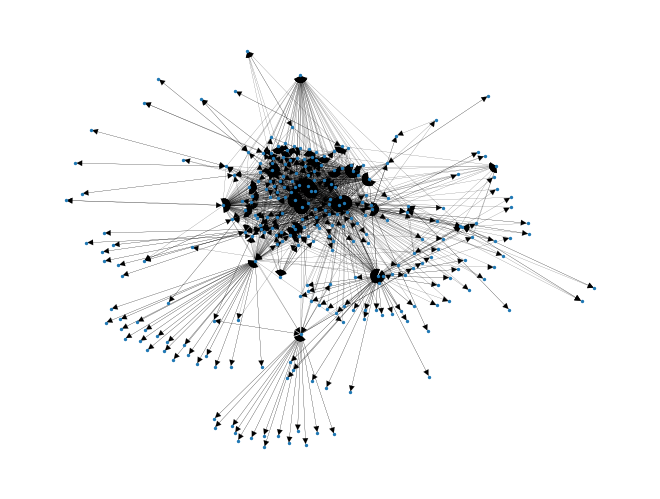

In [ ]:
# Name LSCC network as H
H = G10.subgraph(largest_scc).copy()
nx.draw(H, node_size=2, width=0.1)

In [ ]:
# Convert H to undirected network for commmunity detection: H_und

H_und=H.to_undirected()


In [ ]:
# Apply louvain algorithm to H_und network
from networkx.algorithms.community import louvain_communities

communities=nx.community.louvain_communities(H_und)

# Convert to dict
comm_dict = {}
for cid, comm_nodes in enumerate(communities):
    for n in comm_nodes:
        comm_dict[n] = cid

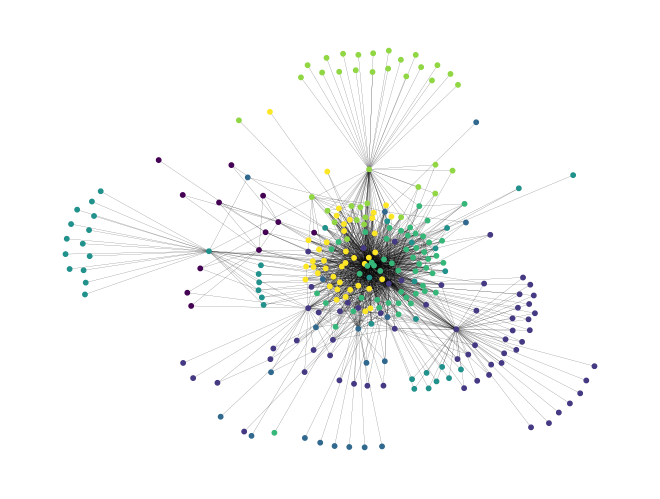

In [ ]:
# Visualize the communities

node_to_comm = {}   # Map each node to its community index

for i, comm in enumerate(communities):
    for node in comm:
        node_to_comm[node] = i

# Build color list in the same order as G_students.nodes()
node_color = [node_to_comm[n] for n in H_und.nodes()]

nx.draw(H_und, node_color=node_color, node_size=10, width=0.1)

In [ ]:
# export graph as a gexf file using networkx's write_gexf function
nx.set_node_attributes(H_und, comm_dict, "community")

nx.write_gexf(H_und, "g10_with_communities.gexf")

from google.colab import files
files.download("g10_with_communities.gexf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Evalute the communites with modularity method

mod=nx.community.modularity(H_und, communities)
print("Modularity:", mod)

Modularity: 0.24589052522805513


## Robustness analysis

In [ ]:
# largeset connected component (LCC) fraction definition

def largest_cc_fraction(G):
  if len(G) == 0:
    return 0.0
  if G.is_directed():
    components = nx.weakly_connected_components(G) # For directed graphs, we use the largest weakly connected component.
  else:
    components = nx.connected_components(G)

  LCC_size= max (len(c)for c in components)
  return LCC_size/G.number_of_nodes()

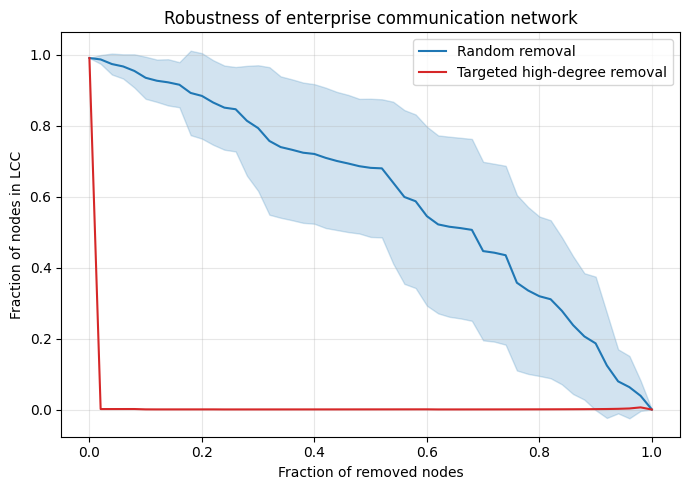

In [ ]:

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

# ---------------------------------------------------------
# 1. Random node removal
# ---------------------------------------------------------
def robustness_random_removal(G,n_runs=20, n_steps=50, seed=None):
   """
    Simulate random node removal and track LCC fraction.

    Parameters
    ----------
    G : networkx.Graph or DiGraph
        Original graph (will not be modified).
    n_runs : int
        Number of random trials to average over.
    n_steps : int
        Number of removal steps (fractions between 0 and 1).
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    fractions_removed : np.ndarray
        Fractions of removed nodes (x-axis).
    mean_lcc : np.ndarray
        Mean LCC fraction over runs (y-axis).
    std_lcc : np.ndarray
        Std of LCC fraction over runs (for error bands).
    """

   rng = np.random.default_rng(seed)
   N = G.number_of_nodes()
   nodes = list(G.nodes())

   fractions_removed = np.linspace(0, 1, n_steps + 1)

  # Store LCC fractions for each run and step
   lcc_all_runs = np.zeros((n_runs, len(fractions_removed)))

   for r in range(n_runs):
      # Work on a copy
      H = G.copy()
      # Random removal order
      removal_order = rng.permutation(nodes)

      # Precompute how many nodes to remove at each step
      for i, frac in enumerate(fractions_removed):
          k = int(round(frac * N))  # number of nodes to remove
          # Reset graph for each step? No: we want progressive removal.
          # So we remove incrementally:
          if i == 0:
              # no removal yet
              pass
          else:
               # remove nodes between previous k and current k
              prev_k = int(round(fractions_removed[i - 1] * N))
              to_remove = removal_order[prev_k:k]
              H.remove_nodes_from(to_remove)

          lcc_all_runs[r, i] = largest_cc_fraction(H)

   mean_lcc = lcc_all_runs.mean(axis=0)
   std_lcc = lcc_all_runs.std(axis=0)

   return fractions_removed, mean_lcc, std_lcc


# ---------------------------------------------------------
# 2. Targeted high-degree node removal
# ---------------------------------------------------------
def robustness_targeted_removal(G, n_steps=50):
    """
    Simulate targeted removal of high-degree nodes and track LCC fraction.
    Degree is computed once at the beginning (static attack).

    Parameters
    ----------
    G : networkx.Graph or DiGraph
        Original graph (will not be modified).
    n_steps : int
        Number of removal steps (fractions between 0 and 1).

    Returns
    -------
    fractions_removed : np.ndarray
        Fractions of removed nodes (x-axis).
    lcc_values : np.ndarray
        LCC fraction at each step (y-axis).
    """
    N = G.number_of_nodes()
    H = G.copy()

    # Compute degree ranking (high to low)
    # For directed graphs, use total degree (in_degree + out_degree)
    if G.is_directed():
        degree_dict = {n: G.in_degree(n) + G.out_degree(n) for n in G.nodes()}
    else:
        degree_dict = dict(G.degree())

    # Sort nodes by degree descending
    sorted_nodes = sorted(degree_dict, key=degree_dict.get, reverse=True)
    sorted_nodes = np.array(sorted_nodes)

    fractions_removed = np.linspace(0, 1, n_steps + 1)
    lcc_values = np.zeros_like(fractions_removed)

    for i, frac in enumerate(fractions_removed):
        k = int(round(frac * N))
        if i == 0:
            # no removal yet
            pass
        else:
            prev_k = int(round(fractions_removed[i - 1] * N))
            to_remove = sorted_nodes[prev_k:k]
            H.remove_nodes_from(to_remove)

        lcc_values[i] = largest_cc_fraction(H)

    return fractions_removed, lcc_values


# ---------------------------------------------------------
# 3. Plotting function
# ---------------------------------------------------------
def plot_robustness(
    frac_rand, mean_rand, std_rand,
    frac_targ, lcc_targ,
    title="Network robustness analysis"
):
    """
    Plot robustness curves for random vs targeted node removal.
    """
    plt.figure(figsize=(7, 5))

    # Random removal with error band
    plt.plot(frac_rand, mean_rand, label="Random removal", color="tab:blue")
    plt.fill_between(
        frac_rand,
        mean_rand - std_rand,
        mean_rand + std_rand,
        color="tab:blue",
        alpha=0.2
    )

    # Targeted removal
    plt.plot(frac_targ, lcc_targ, label="Targeted high-degree removal", color="tab:red")

    plt.xlabel("Fraction of removed nodes")
    plt.ylabel("Fraction of nodes in LCC")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# 4. real network use
# ---------------------------------------------------------
if __name__ == "__main__":

    G = G10  # use the enterprise network

    # Random removal robustness
    frac_rand, mean_rand, std_rand = robustness_random_removal(
        G,
        n_runs=30,
        n_steps=50,
        seed=42
    )

    # Targeted high-degree removal robustness
    frac_targ, lcc_targ = robustness_targeted_removal(
        G,
        n_steps=50
    )

    # Plot comparison
    plot_robustness(
        frac_rand, mean_rand, std_rand,
        frac_targ, lcc_targ,
        title="Robustness of enterprise communication network"
    )



In [ ]:

sorted_nodes = sorted(degree_dict, key=degree_dict.get, reverse=True)
sorted_nodes = np.array(sorted_nodes)

top10_nodes = sorted_nodes[:10]
top10_nodes

top20_nodes = sorted_nodes[:20]
top20_nodes


array([  4,  12,   8,  17, 107,   2,  64, 126,   6,  39,  80,  49,  45,
       151,  42,  98,   9,  70,  54,  35])

In [ ]:
## test if I remove node 4 and node 12
# Make a copy so original G is safe
G10_2 = G10.copy()

# Remove nodes 4 and 12
G10_2.remove_nodes_from([4, 12])

# Compute largest connected component size
lcc_size = len(max(nx.weakly_connected_components(G10_2), key=len))

print("lcc fraction after removing nodes 4 and 12:", lcc_size/G10.number_of_nodes())
print("Number of components:", nx.number_weakly_connected_components(G10_2))

lcc fraction after removing nodes 4 and 12: 0.4241576450553461
Number of components: 4655


In [ ]:
## test if I remove 4, 12,8,17,107
# Make a copy so original G is safe
G10_3 = G10.copy()

# Remove nodes 4, 12,8,17,107
G10_3.remove_nodes_from([4,12,8,17,107])

# Compute largest connected component size
lcc_size = len(max(nx.weakly_connected_components(G10_3), key=len))

print("lcc fraction after removing 5 nodes:", lcc_size/G10.number_of_nodes())
print("Number of components:", nx.number_weakly_connected_components(G10_3))

lcc fraction after removing nodes 4, 12,8,17,107: 0.337915095487167
Number of components: 5361


In [ ]:
## test if I remove 4,  12,   8,  17, 107,   2,  64, 126,   6,  39
# Make a copy so original G is safe
G10_4 = G10.copy()

# Remove nodes 4, 12, 8, 17, 107, 2, 64, 126, 6, 39
G10_4.remove_nodes_from([4, 12, 8, 17, 107, 2, 64, 126, 6, 39])

# Compute largest connected component size
lcc_size = len(max(nx.weakly_connected_components(G10_4), key=len))

print("lcc fraction after removing 10 nodes :", lcc_size/G10.number_of_nodes())
print("Number of components:", nx.number_weakly_connected_components(G10_4))

lcc fraction after removing nodes 4, 12, 8, 17, 107, 2, 64, 126, 6, 39: 0.2552000973117626
Number of components: 6036


In [ ]:
## test if I remove 4,  12,   8,  17, 107,   2,  64, 126,   6,  39,  80,  49,  45,151,  42,  98,   9,  70,  54,  35

# Make a copy so original G is safe
G10_5 = G10.copy()

# Remove nodes 4,  12,   8,  17, 107,   2,  64, 126,   6,  39,  80,  49,  45,151,  42,  98,   9,  70,  54,  35

G10_5.remove_nodes_from([  4,  12,   8,  17, 107,   2,  64, 126,   6,  39,  80,  49,  45, 151,  42,  98,   9,  70,  54,  35])

# Compute largest connected component size
lcc_size = len(max(nx.weakly_connected_components(G10_5), key=len))

print("lcc fraction after removing 20 nodes :", lcc_size/G10.number_of_nodes())
print("Number of components:", nx.number_weakly_connected_components(G10_5))

lcc fraction after removing 20 nodes : 0.1503466731541175
Number of components: 6887


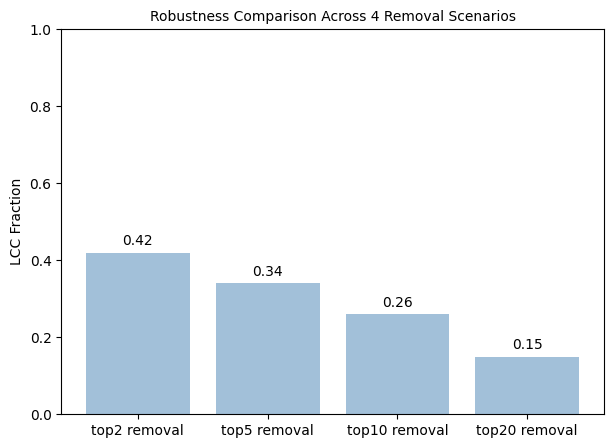

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


lcc_fractions = [
    0.42,
    0.34,
    0.26,
    0.15
]

num_components = [
    4655,
    5361,
    6036,
    6887
]

labels = ["top2 removal", "top5 removal", "top10 removal", "top20 removal"]

x = np.arange(len(labels))

fig, ax1 = plt.subplots(figsize=(7,5))

# Bar plot for LCC fraction
ax1.bar(x, lcc_fractions, color="steelblue", alpha=0.5)
ax1.set_ylabel("LCC Fraction", fontsize=10)
ax1.set_ylim(0, 1)

# Add labels
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_title("Robustness Comparison Across 4 Removal Scenarios", fontsize=10)

# Annotate values
for i, v in enumerate(lcc_fractions):
    ax1.text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.show()
